In [14]:
import sys
sys.path.append('../SlitMaker')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib as mpl
import matplotlib.image as mpimg
from matplotlib.collections import LineCollection
%matplotlib inline
from scipy.optimize import curve_fit
from scipy.optimize import minimize_scalar
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.modeling.models import BlackBody
from astropy.constants import c
from astropy import units as u
from astropy.units import photometric
from synphot import SourceSpectrum, Observation, SpectralElement
from synphot.units import VEGAMAG
import slitoverlaymaker
import overlayfunction
import math

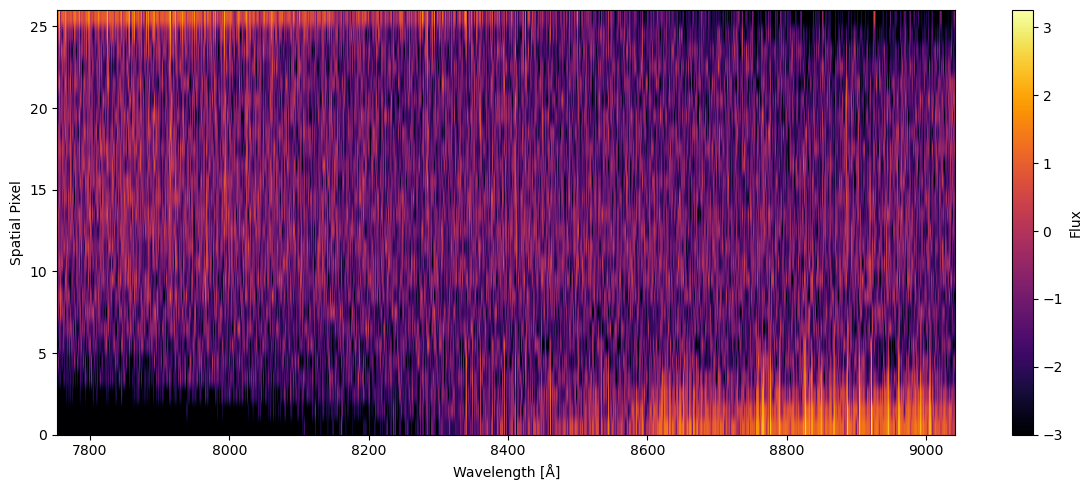

In [38]:
filename = "./spec2dkdg63/jan2019/slit.KDG63A.01R.fits.gz"
with fits.open(filename) as hdul:
    flux = hdul[1].data[0]['FLUX']       # shape: (30, 4096)
    wavelength = hdul[1].data[0]['LAMBDA0']  # shape: (4096,)

    # Define axis extents
    extent = [wavelength[0], wavelength[-1], 0, flux.shape[0]]  # [Xmin, Xmax, Ymin, Ymax]
    flux_log = np.log10(np.clip(flux, a_min=1e-3, a_max=None))
    # Plot
    plt.figure(figsize=(12, 5))
    plt.imshow(flux_log, aspect='auto', cmap='inferno', origin='lower', extent=extent)
    plt.xlabel("Wavelength [Å]")
    plt.ylabel("Spatial Pixel")
    plt.colorbar(label="Flux")
    plt.tight_layout()
    plt.show()